In [38]:
import sklearn
from sklearn.datasets import make_circles

In [39]:
n_samples = 1000
x,y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [40]:
len(x),len(y)

(1000, 1000)

In [41]:
import pandas as pd
circles = pd.DataFrame({'x1':x[:,0],
                        'x2':x[:,1],
                        'label':y})
circles

,x1,x2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


In [62]:
circles.label.value_counts()

label
1    500
0    500
Name: count, dtype: int64

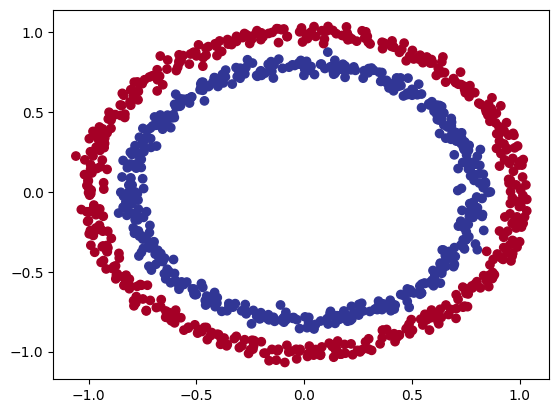

In [42]:
import matplotlib.pyplot as plt 
plt.scatter(x=x[:,0],y=x[:,1],c=y,cmap=plt.cm.RdYlBu)


In [43]:
x.shape,y.shape

((1000, 2), (1000,))

In [44]:
import torch 
x = torch.from_numpy(x).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [45]:
type(x)

torch.Tensor

In [46]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,train_size=0.8,random_state=42)

In [47]:
len(x_train),len(x_test)

(800, 200)

## building the model

In [48]:
from torch import nn

device ="mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [49]:
x_train.shape

torch.Size([800, 2])

In [50]:
class circleModelv0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2,out_features=5)
        self.layer_2 = nn.Linear(in_features=5,out_features=1)

    def forward(self,x):
        return self.layer_2(self.layer_1(x))

model_0 = circleModelv0().to(device)
model_0

circleModelv0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

for smaller models we can also use sequential()

In [51]:
class circleModelv1(nn.Module):
    def __init__(self):
        super().__init__()
        self.two_layers = nn.Sequential(
            nn.Linear(in_features=2,out_features=5),
            nn.Linear(in_features=5,out_features=1)
        )

    def forward(self,x):
        return two_layers(x)

model_1 = circleModelv1().to(device)
model_1

circleModelv1(
  (two_layers): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [52]:
model_0.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]], device='mps:0')),
             ('layer_1.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='mps:0')),
             ('layer_2.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='mps:0')),
             ('layer_2.bias', tensor([-0.2060], device='mps:0'))])

In [53]:
with torch.inference_mode(): 
    untrained_pred = model_0(x_test.to(device))
torch.round(untrained_pred)

tensor([[-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-0.],
        [-

which loss function to use ?

for regsression model we use MAE or MSE 

for classification model we use binary cross entropy or categorical cross entropy 

## BCELoss():
it requires the input to already have gone through a sigmoid dunction 

## BCEWithLogitsLoss():
has sigmoid built in hence more stable 

In [54]:
loss_fn = nn.BCEWithLogitsLoss()
optim = torch.optim.SGD(params = model_0.parameters(),lr=0.1)

In [55]:
list(model_0.parameters())

[Parameter containing:
 tensor([[ 0.5406,  0.5869],
         [-0.1657,  0.6496],
         [-0.1549,  0.1427],
         [-0.3443,  0.4153],
         [ 0.6233, -0.5188]], device='mps:0', requires_grad=True),
 Parameter containing:
 tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410], device='mps:0',
        requires_grad=True),
 Parameter containing:
 tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]], device='mps:0',
        requires_grad=True),
 Parameter containing:
 tensor([-0.2060], device='mps:0', requires_grad=True)]

In [56]:
def accuracy_fn(y_true,y_pred):
    correct = torch.eq(y_true,y_pred).sum().item()
    acc = (correct/len(y_pred))*100
    return acc


In [57]:
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(x_test.to(device))[:5]
y_logits

tensor([[-0.1269],
        [-0.0967],
        [-0.1908],
        [-0.1089],
        [-0.1667]], device='mps:0')

In [58]:
y_pred_probs = torch.sigmoid(y_logits)
torch.round(y_pred_probs),y_test[:5]
torch.eq(y_pred_probs.squeeze(),y_test[:5].to(device))

tensor([False, False, False, False, False], device='mps:0')

In [59]:
torch.manual_seed(42)
epochs = 100
x_test,y_test = x_test.to(device),y_test.to(device)
x_train,y_train = x_train.to(device),y_train.to(device)  
for epoch in range(epochs):
    model_0.train()
    y_logits = model_0(x_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train,y_pred=y_pred)
    optim.zero_grad()
    loss.backward()
    optim.step()
    
    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(x_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test,y_pred=test_pred)
    if epoch%10 ==0:
        print(f'epoch: {epoch}   | Loss: {loss:.5f}.   | accuracy: {acc: .2f}   | test loss: {test_loss: .5f}   | test acc: {test_acc:.2f}')

epoch: 0   | Loss: 0.69569.   | accuracy:  50.00   | test loss:  0.69721   | test acc: 50.00
epoch: 10   | Loss: 0.69403.   | accuracy:  50.00   | test loss:  0.69615   | test acc: 50.00
epoch: 20   | Loss: 0.69343.   | accuracy:  46.00   | test loss:  0.69585   | test acc: 48.50
epoch: 30   | Loss: 0.69321.   | accuracy:  49.00   | test loss:  0.69577   | test acc: 47.50
epoch: 40   | Loss: 0.69312.   | accuracy:  49.50   | test loss:  0.69573   | test acc: 46.50
epoch: 50   | Loss: 0.69308.   | accuracy:  50.38   | test loss:  0.69569   | test acc: 46.50
epoch: 60   | Loss: 0.69306.   | accuracy:  50.50   | test loss:  0.69564   | test acc: 46.50
epoch: 70   | Loss: 0.69305.   | accuracy:  50.50   | test loss:  0.69559   | test acc: 46.50
epoch: 80   | Loss: 0.69304.   | accuracy:  50.75   | test loss:  0.69553   | test acc: 46.50
epoch: 90   | Loss: 0.69303.   | accuracy:  50.38   | test loss:  0.69547   | test acc: 46.50


In [60]:
x_train,y_train


(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         ...,
         [ 0.0157, -1.0300],
         [ 1.0110,  0.1680],
         [ 0.5578, -0.5709]], device='mps:0'),
 tensor([1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.,
         0., 1., 1., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1.,
         1., 1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 1.,
         1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
         1., 1., 0., 0., 0., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
         0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
         0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 1., 0., 1.,
         1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 1., 1., 1., 0., 0., 1., 1., 0.,
         0., 1., 1., 1., 1., 0., 1., 1., 0., 0., 0., 1., 1., 1., 

In [65]:
import requests 
from pathlib import Path

if Path('helper_function.py').is_file():
    print("exist")

exist


In [66]:
from helper_function import plot_predictions,plot_decision_boundary

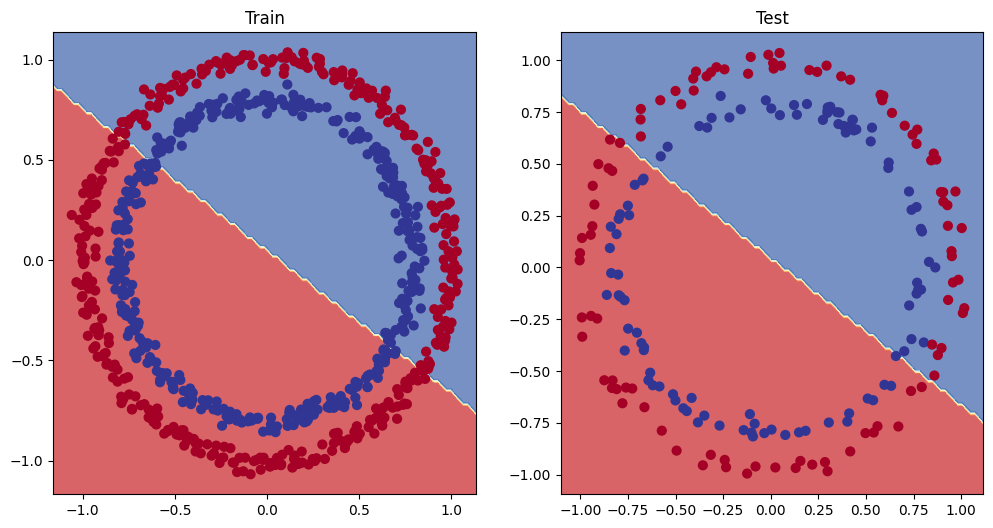

In [67]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, x_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, x_test, y_test)